# **Fetch - Data Analyst Take Home**

### To start the analysis, I uploaded all the data files (Users, Transactions, and Products) into Google Colab. This lets me access and work with the data directly in the notebook environment.






In [1]:
#Upload User CSV file to Colab

from google.colab import files


user = files.upload()

Saving USER_TAKEHOME.csv to USER_TAKEHOME.csv


In [2]:
#Upload Transactions CSV file to Colab

from google.colab import files


transactions = files.upload()

Saving TRANSACTION_TAKEHOME.csv to TRANSACTION_TAKEHOME.csv


In [3]:
#Upload Products CSV file to Colab

from google.colab import files


products = files.upload()

Saving PRODUCTS_TAKEHOME.csv to PRODUCTS_TAKEHOME.csv


## I will be working on the User table first.

### I loaded the files into individual DataFrames using pandas. This made it easier to inspect, clean, and analyze the data using built-in functions.

In [4]:
#Read each CSV file into a DataFrame

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
user = pd.read_csv("USER_TAKEHOME.csv")
transactions = pd.read_csv("TRANSACTION_TAKEHOME.csv")
products = pd.read_csv("PRODUCTS_TAKEHOME.csv")


### I printed the top rows from the User DataFrame to get a quick feel for the structure of the data—what columns are included, what kind of values they hold, and if anything immediately looked off.

In [ ]:
#Viewed the first 5 rows of User table
user[:5]

,ID,CREATED_DATE,BIRTH_DATE,STATE,LANGUAGE,GENDER
0,5ef3b4f17053ab141787697d,2020-06-24 20:17:54.000 Z,2000-08-11 00:00:00.000 Z,CA,es-419,female
1,5ff220d383fcfc12622b96bc,2021-01-03 19:53:55.000 Z,2001-09-24 04:00:00.000 Z,PA,en,female
2,6477950aa55bb77a0e27ee10,2023-05-31 18:42:18.000 Z,1994-10-28 00:00:00.000 Z,FL,es-419,female
3,658a306e99b40f103b63ccf8,2023-12-26 01:46:22.000 Z,NaN,NC,en,NaN
4,653cf5d6a225ea102b7ecdc2,2023-10-28 11:51:50.000 Z,1972-03-19 00:00:00.000 Z,PA,en,female


### Logically, a user's birth date should be earlier than the date they created their account. I filtered the data to flag any rows where this wasn’t true, as these likely point to data entry errors.

In [ ]:
# Checked for rows where birth_date is after created_date
invalid_rows = user[user['BIRTH_DATE'] > user['CREATED_DATE']]
print(invalid_rows)

                             ID               CREATED_DATE  \
41974  5f31fc048fa1e914d38d6952  2020-08-11 02:01:41.000 Z   

                      BIRTH_DATE STATE LANGUAGE GENDER  
41974  2020-10-02 15:27:28.000 Z    CA      NaN    NaN  


*We notice here that in one entry, the created_date is before the birth_date which is not logically correct.*

### I used the info() function to see column types, number of non-null values, and overall size of the User dataset. This helped identify potential issues like missing values or incorrectly formatted data types.

In [ ]:
#Used .info() to understand the structure of User table
user.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   ID            100000 non-null  object
 1   CREATED_DATE  100000 non-null  object
 2   BIRTH_DATE    96325 non-null   object
 3   STATE         95188 non-null   object
 4   LANGUAGE      69492 non-null   object
 5   GENDER        94108 non-null   object
dtypes: object(6)
memory usage: 4.6+ MB


### I checked to ensure all date formats were consistent across the column, so that later filtering and sorting operations would work correctly.

In [ ]:
#Identified rows with unusual or invalid date formats in BIRTH_DATE

from dateutil import parser

def get_format(date_str):
    try:
        parsed = parser.parse(date_str, fuzzy=False)
        return parsed.strftime("%Y-%m-%d %H:%M:%S.%f %Z")
    except:
        return "Invalid"

user['parsed_format'] = user['BIRTH_DATE'].astype(str).apply(get_format)
print(user['parsed_format'].value_counts())

parsed_format
Invalid                           3675
1970-01-01 00:00:00.000000 UTC    1272
1979-12-11 08:00:00.000000 UTC      63
2000-12-12 00:00:00.000000 UTC      28
2000-12-31 00:00:00.000000 UTC      23
                                  ... 
1999-09-23 13:59:05.000000 UTC       1
2010-04-29 00:00:00.000000 UTC       1
1969-04-26 06:00:00.000000 UTC       1
2002-09-21 05:19:02.000000 UTC       1
1987-05-26 04:00:00.000000 UTC       1
Name: count, Length: 54722, dtype: int64


*There are 3675 values in the Birth_Date column, that don't follow the date format of the others in the same column.*

In [ ]:
#Identified rows with unusual or invalid date formats in CREATED_DATE

from dateutil import parser

def get_format(date_str):
    try:
        parsed = parser.parse(date_str, fuzzy=False)
        return parsed.strftime("%Y-%m-%d %H:%M:%S.%f %Z")
    except:
        return "Invalid"

user['parsed_format'] = user['CREATED_DATE'].astype(str).apply(get_format)
print(user['parsed_format'].value_counts())

parsed_format
2022-07-06 19:19:26.000000 UTC    2
2024-04-08 20:57:19.000000 UTC    2
2020-02-16 17:04:11.000000 UTC    2
2022-09-27 14:35:49.000000 UTC    2
2020-05-04 01:01:40.000000 UTC    2
                                 ..
2024-07-24 19:33:12.000000 UTC    1
2020-12-01 05:25:08.000000 UTC    1
2022-04-24 12:16:45.000000 UTC    1
2021-08-15 18:50:01.000000 UTC    1
2017-12-18 18:19:38.000000 UTC    1
Name: count, Length: 99942, dtype: int64


### To visualize where data is missing, I built a bar chart. This made it easier to spot which columns have the most gaps and might require cleaning or imputation.

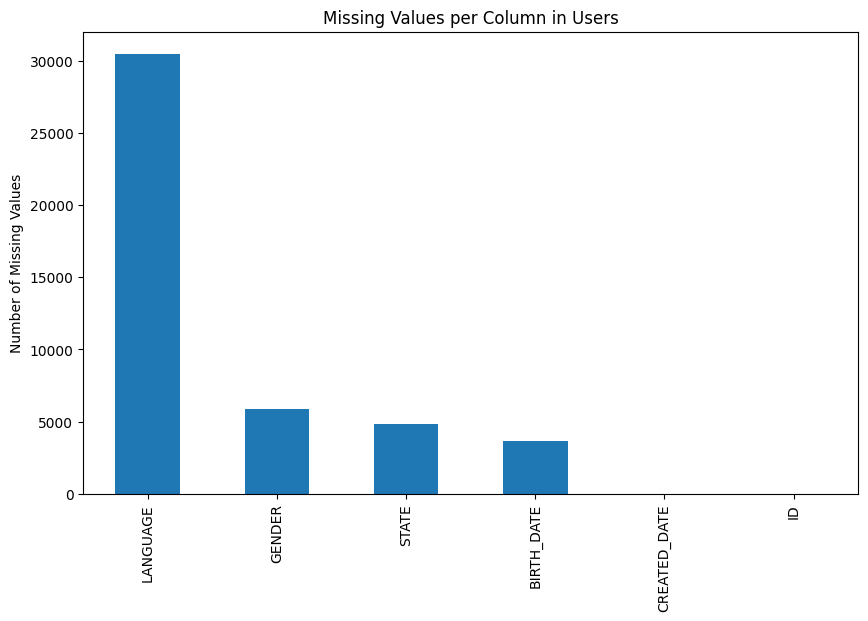

In [ ]:
#Created a bar chart showing missing values per column in Users

(user.isnull().sum()
   .sort_values(ascending=False)
   .plot(kind='bar', figsize=(10,6), title='Missing Values per Column in Users'))
plt.ylabel('Number of Missing Values')
plt.show()

*The missing values are mainly concentrated in the gender column, followed by gender, state and birth_date.*

### I also created a heatmap to visualize missing data across the dataset. This gives a more detailed view of how missing values are distributed and whether there's any pattern to them.

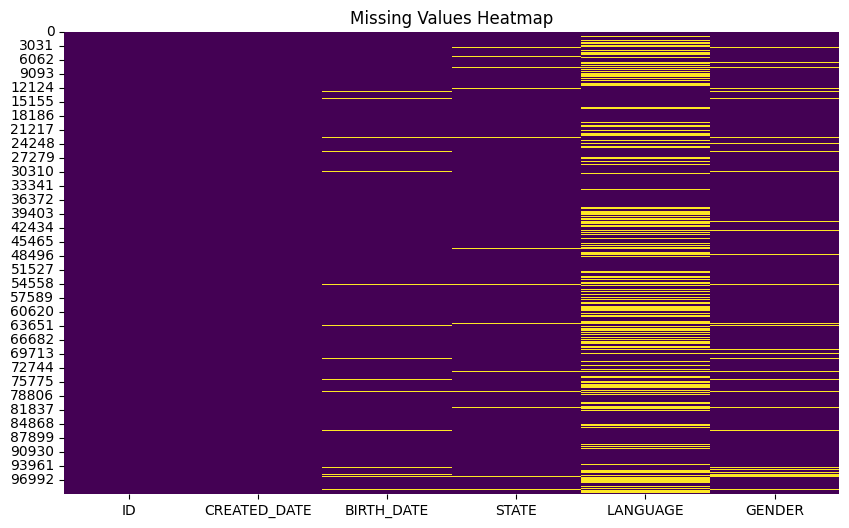

In [ ]:
#Plot a heatmap of missing values for Users

plt.figure(figsize=(10,6))
sns.heatmap(user.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()

*The rows where there is missing fields in the last 4 columns is primarily in the 2nd half of the dataset.*

I checked how many times each user ID. Duplicate IDs could suggest issues like repeated records or the same ID being used for different users.

In [ ]:
# Used value counts on IDs to check for repeats

value_counts = user['ID'].value_counts()
value_counts

,count
ID,
624791449082231a3d7c56de,1
65464e28909604bae908771a,1
5fd8db2baf13c1128fe30e75,1
656e9ec99cb6a4f05dcaaec6,1
5eae3f6179a1cb1416d153d5,1
...,...
653cf5d6a225ea102b7ecdc2,1
658a306e99b40f103b63ccf8,1
6477950aa55bb77a0e27ee10,1


*There are no duplicates in the ID's.*

### I used value counts to surface inconsistencies like  slight differences in wording so they could be cleaned and standardized.

In [5]:
value_counts = user['STATE'].value_counts()
value_counts

,count
STATE,
TX,9028
FL,8921
CA,8589
NY,5703
IL,3794
GA,3718
PA,3644
OH,3519
NC,3399


In [ ]:
value_counts = user['LANGUAGE'].value_counts()
value_counts

,count
LANGUAGE,
en,63403
es-419,6089


In [ ]:
value_counts = user['GENDER'].value_counts()
value_counts

,count
GENDER,
female,64240
male,25829
transgender,1772
prefer_not_to_say,1350
non_binary,473
unknown,196
not_listed,180
Non-Binary,34
not_specified,28


*Non-Binary and non_binary are the same thing but due to capitalization and punctuation, they are labelled seperately.*

### I looked for rows that were entirely repeated, which could skew analysis or inflate counts. Removing duplicates helps ensure accuracy.




In [ ]:
duplicate_rows = user[user.duplicated()]
print(f'Duplicates found: {len(duplicate_rows)}')

Duplicates found: 0


## Now, I will be looking into the Transactions Table.

### A quick glance at the first few rows of the Transactions table helped me understand the layout and catch any obvious issues before diving deeper.

In [ ]:
#Viewed the first 5 rows of Transactions table

transactions[:5]

,RECEIPT_ID,PURCHASE_DATE,SCAN_DATE,STORE_NAME,USER_ID,BARCODE,FINAL_QUANTITY,FINAL_SALE
0,0000d256-4041-4a3e-adc4-5623fb6e0c99,2024-08-21,2024-08-21 14:19:06.539 Z,WALMART,63b73a7f3d310dceeabd4758,1.530001e+10,1.00,
1,0001455d-7a92-4a7b-a1d2-c747af1c8fd3,2024-07-20,2024-07-20 09:50:24.206 Z,ALDI,62c08877baa38d1a1f6c211a,NaN,zero,1.49
2,00017e0a-7851-42fb-bfab-0baa96e23586,2024-08-18,2024-08-19 15:38:56.813 Z,WALMART,60842f207ac8b7729e472020,7.874223e+10,1.00,
3,000239aa-3478-453d-801e-66a82e39c8af,2024-06-18,2024-06-19 11:03:37.468 Z,FOOD LION,63fcd7cea4f8442c3386b589,7.833997e+11,zero,3.49
4,00026b4c-dfe8-49dd-b026-4c2f0fd5c6a1,2024-07-04,2024-07-05 15:56:43.549 Z,RANDALLS,6193231ae9b3d75037b0f928,4.790050e+10,1.00,


### I flagged entries where purchase_dates came after scan_dates, since those are likely errors.

In [ ]:
# Checked for rows where purchase_date is after scan_date

invalid_rows = transactions[transactions['PURCHASE_DATE'] > transactions['SCAN_DATE']]
print(invalid_rows)

                                 RECEIPT_ID PURCHASE_DATE  \
51     008c1dcc-0f96-4b04-98c8-2a2bb63ef89d    2024-07-21   
455    04a320ed-2903-45e5-8fd7-6eaf08daef32    2024-06-29   
494    05023b3d-5f83-47a7-a17c-8e8521d0bc94    2024-09-08   
675    06ce3da3-a588-4c37-93b4-0b6d11e42704    2024-06-22   
870    08d0e78f-3e63-40a3-8eb0-73fdf76da52c    2024-06-22   
...                                     ...           ...   
46034  08d0e78f-3e63-40a3-8eb0-73fdf76da52c    2024-06-22   
46539  718aa730-b62f-4e18-8dba-1d7105dac341    2024-09-05   
46941  af2b818f-4a92-4e98-958c-65f2ce0b271d    2024-06-15   
47653  72bb7b71-d958-4a46-ae62-43abdeb0e693    2024-06-15   
47837  99c2e8dc-9dc7-4267-9342-0b19c3fb35a0    2024-06-15   

                       SCAN_DATE            STORE_NAME  \
51     2024-07-20 19:54:23.133 Z               WALMART   
455    2024-06-28 11:03:31.783 Z  DOLLAR GENERAL STORE   
494    2024-09-07 22:22:29.903 Z             SHOP RITE   
675    2024-06-21 12:34:15.665 Z   

*I came across 94 rows where the order for purchase_date and scan_date did not follow the regular order as the rest of the table.*

### I used .info() confirm whether data types matched expectations and highlighted any missing or misclassified values.

In [ ]:
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   RECEIPT_ID      50000 non-null  object 
 1   PURCHASE_DATE   50000 non-null  object 
 2   SCAN_DATE       50000 non-null  object 
 3   STORE_NAME      50000 non-null  object 
 4   USER_ID         50000 non-null  object 
 5   BARCODE         44238 non-null  float64
 6   FINAL_QUANTITY  50000 non-null  object 
 7   FINAL_SALE      50000 non-null  object 
 8   parsed_format   50000 non-null  object 
dtypes: float64(1), object(8)
memory usage: 3.4+ MB


### I checked if all date entries followed the same structure. Format mismatches can break downstream operations, so consistency is key.

In [ ]:
#Identified rows with unusual or invalid date formats in SCAN_DATE


def get_format(date_str):
    try:
        parsed = parser.parse(date_str, fuzzy=False)
        return parsed.strftime("%Y-%m-%d %H:%M:%S.%f %Z")
    except:
        return "Invalid"

transactions['parsed_format'] = transactions['SCAN_DATE'].astype(str).apply(get_format)
print(transactions['parsed_format'].value_counts())

parsed_format
2024-09-08 20:00:42.348000 UTC    12
2024-09-08 19:39:01.589000 UTC     8
2024-09-07 17:30:53.326000 UTC     8
2024-09-07 14:52:46.822000 UTC     8
2024-09-08 13:30:53.944000 UTC     8
                                  ..
2024-08-14 12:22:37.353000 UTC     2
2024-06-17 01:12:11.893000 UTC     2
2024-09-03 16:14:23.976000 UTC     2
2024-06-15 19:54:15.878000 UTC     2
2024-08-28 14:49:33.387000 UTC     2
Name: count, Length: 24440, dtype: int64


In [ ]:
#Identified rows with unusual or invalid date formats in PURCHASED_DATE

def get_format(date_str):
    try:
        parsed = parser.parse(date_str, fuzzy=False)
        return parsed.strftime("%Y-%m-%d ")
    except:
        return "Invalid"

transactions['parsed_format'] = transactions['PURCHASE_DATE'].astype(str).apply(get_format)
print(transactions['parsed_format'].value_counts())

parsed_format
2024-06-15     774
2024-07-03     772
2024-07-01     752
2024-08-03     720
2024-07-13     712
              ... 
2024-09-07     428
2024-08-21     422
2024-09-06     394
2024-09-04     390
2024-09-08     282
Name: count, Length: 89, dtype: int64


*The formatting of the dates for both Scan_Date and Purchase_Date are consistent across the columns.*

### I made a bar chart showing how much data is missing from each column. This helped prioritize which columns might need cleaning or special handling.


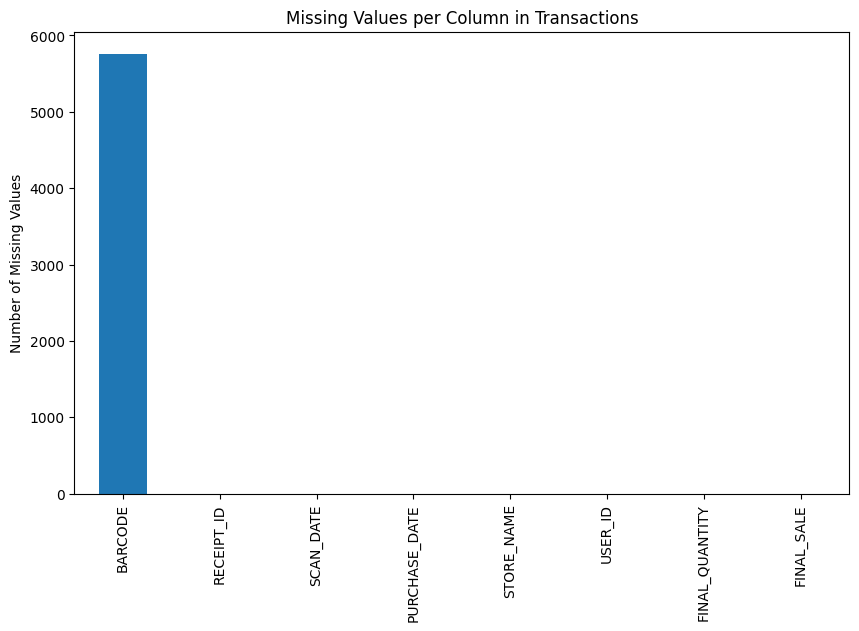

In [ ]:
#Created a bar chart showing missing values per column in Transactions

(transactions.isnull().sum()
   .sort_values(ascending=False)
   .plot(kind='bar', figsize=(10,6), title='Missing Values per Column in Transactions'))
plt.ylabel('Number of Missing Values')
plt.show()

*The only column with missing values is 'Barcode'.*

### To spot patterns in missing values across the dataset, I used a heatmap. This view makes it easier to identify if certain rows or columns have more gaps than others.

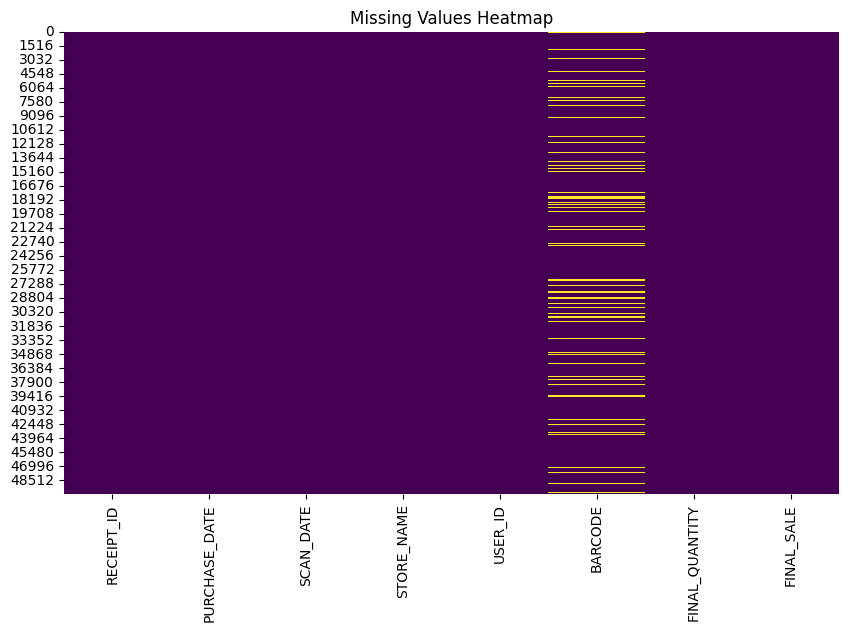

In [ ]:
#Plot a heatmap of missing values for Transactions

plt.figure(figsize=(10,6))
sns.heatmap(transaction.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()

*While, the missing values of barcode are scattered, they are highly concentrated towards the middle rows.*

### I applied fuzzy matching to find entries in text fields that were likely the same but spelled differently. Fixing these avoids splitting results across multiple variations of the same value.

In [ ]:
pip install rapidfuzz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 16.0 MB/s eta 0:00:00


In [ ]:
# Used rapidfuzz to catch misspellings in columns like store_name

unique_values = transactions['STORE_NAME'].unique()
from rapidfuzz import fuzz, process

for word in unique_values:
    matches = process.extract(word, unique_values, scorer=fuzz.ratio, limit=3)
    for match in matches:
        if match[0] != word and match[1] > 80:
            print(f"'{word}' is close to '{match[0]}' with {match[1]}% similarity")

'TARGET' is close to 'TARJET' with 83.33333333333334% similarity
'MACEY'S' is close to 'MACY'S' with 92.3076923076923% similarity
'WINCO FOODS' is close to 'INCO FOODS' with 95.23809523809523% similarity
'FRED MEYER' is close to 'REDMEYER' with 88.88888888888889% similarity
'FRED MEYER' is close to 'FREAMEYER' with 84.21052631578947% similarity
'FIVE BELOW' is close to 'FIVE BELOV' with 90.0% similarity
'PHARMACY' is close to 'IPHARMACY' with 94.11764705882352% similarity
'FASTRAC' is close to 'FAST TRACK' with 82.35294117647058% similarity
'BJ'S WHOLESALE CLUB' is close to 'IL''S WHIOLESALE CLUB' with 85.0% similarity
'MARC'S' is close to 'MACY'S' with 83.33333333333334% similarity
'PIONEER SUPERMARKETS' is close to 'SUPER SUPERMARKET' with 81.08108108108108% similarity
'KING SOOPERS' is close to 'KING SOOPERS FUEL' with 82.75862068965517% similarity
'FESTIVAL FOODS' is close to 'FIESTA FOODS' with 84.61538461538461% similarity
'MARKET' is close to 'MARKETON' with 85.71428571428572% s

*I made a note of the incorrect spellings within the column:*

*1. Target – Tarjet*

*2. Macy's – Macey's*

*3. Winco Foods – Inco Foods*

*4. Fred Meyer – Redmeyer*

*5. Fred Meyer – Freameyer*

*6. Five Below – Five Belov*

*7. Pharmacy – iPharmacy*

*8. Fastrac – Fast Track*

*9. Ponte Fresco – Ponts Fresco*

*10. Northgate Market – eNorthgate Market*

*11. Northgate Market – Northoate Marketr*

*12. Price Cutter – Price Utter*

### I used value counts on columns to spot spelling inconsistencies that should be standardized.

In [ ]:
value_counts = transactions['FINAL_QUANTITY'].value_counts()
value_counts

,count
FINAL_QUANTITY,
1.00,35698
zero,12500
2.00,1285
3.00,184
4.00,139
...,...
2.04,1
3.69,1
0.70,1


*The values vary between letters and numbers which are inconsistent, they need to be standardized.*

### I scanned for rows that were entirely identical, which are usually redundant and can distort metrics if not removed.

In [ ]:
duplicate_rows = transaction[transaction.duplicated()]
print(f'Duplicates found: {len(duplicate_rows)}')

Duplicates found: 171


*There are 171 duplicate rows that should be removed during cleaning.*

## Now, I moved to the Products Table

### I used .head() to quickly look at the top of each dataset and get a basic sense of what the data looks like and whether anything jumps out as unusual.

In [ ]:
products[:5]

,CATEGORY_1,CATEGORY_2,CATEGORY_3,CATEGORY_4,MANUFACTURER,BRAND,BARCODE
0,Health & Wellness,Sexual Health,Conductivity Gels & Lotions,NaN,NaN,NaN,7.964944e+11
1,Snacks,Puffed Snacks,Cheese Curls & Puffs,NaN,NaN,NaN,2.327801e+10
2,Health & Wellness,Hair Care,Hair Care Accessories,NaN,PLACEHOLDER MANUFACTURER,ELECSOP,4.618178e+11
3,Health & Wellness,Oral Care,Toothpaste,NaN,COLGATE-PALMOLIVE,COLGATE,3.500047e+10
4,Health & Wellness,Medicines & Treatments,Essential Oils,NaN,MAPLE HOLISTICS AND HONEYDEW PRODUCTS INTERCHA...,MAPLE HOLISTICS,8.068109e+11


### I used .info() to give me a quick summary of each column such as, the data type and how complete the data is.

In [ ]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 845552 entries, 0 to 845551
Data columns (total 7 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   CATEGORY_1    845441 non-null  object 
 1   CATEGORY_2    844128 non-null  object 
 2   CATEGORY_3    784986 non-null  object 
 3   CATEGORY_4    67459 non-null   object 
 4   MANUFACTURER  619078 non-null  object 
 5   BRAND         619080 non-null  object 
 6   BARCODE       841527 non-null  float64
dtypes: float64(1), object(6)
memory usage: 45.2+ MB


### Sometimes entire rows are repeated. I checked for and flagged these to avoid double-counting in analysis.




In [ ]:
duplicate_rows = products[products.duplicated()]
print(f'Duplicates found: {len(duplicate_rows)}')

Duplicates found: 215


*There are 215 rows that have been duplicated.*

### I made a  bar chart which highlighted where most of the missing values were concentrated.

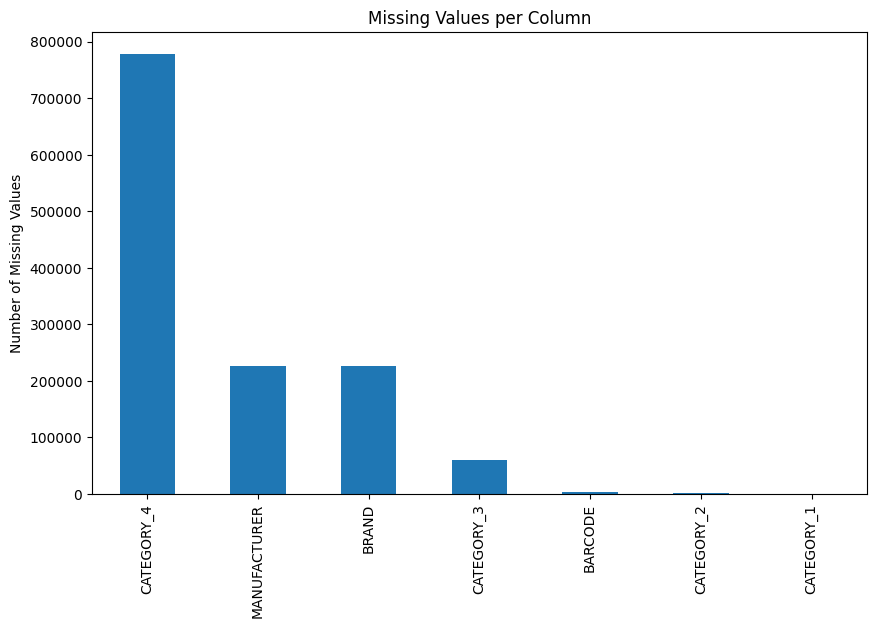

In [ ]:
(products.isnull().sum()
   .sort_values(ascending=False)
   .plot(kind='bar', figsize=(10,6), title='Missing Values per Column'))
plt.ylabel('Number of Missing Values')
plt.show()

*The missing values are mainly in the 'Category_4' column.*

### I used a heatmap to show patterns in missing data, helping identify if any particular rows or combinations were affected.

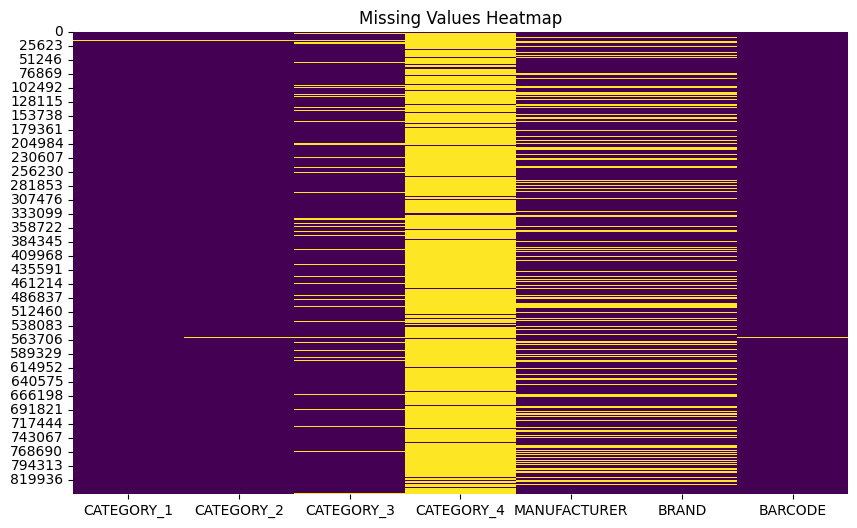

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(products.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()

*There isn't really a pattern in which rows have most of the values missing.*

### I used value counts helped me spot different spellings or variations of the same value.

In [ ]:
value_counts = products['CATEGORY_1'].value_counts()
value_counts

,count
CATEGORY_1,
Health & Wellness,512695
Snacks,324817
Beverages,3990
Pantry,871
Apparel & Accessories,846
Dairy,602
Needs Review,547
Alcohol,503
Home & Garden,115


In [ ]:
value_counts = products['CATEGORY_2'].value_counts()
value_counts

,count
CATEGORY_2,
Candy,121036
Hair Care,111482
Medicines & Treatments,99118
Bath & Body,81469
Skin Care,62587
...,...
Baby & Toddler Feeding,1
Household Appliances,1
Shipping Supplies,1


In [ ]:
value_counts = products['CATEGORY_4'].value_counts()
value_counts

,count
CATEGORY_4,
Lip Balms,9737
Already Popped Popcorn,6974
Sleep Aids,4978
Hair Brushes & Combs,4724
Women's Shaving Gel & Cream,3874
...,...
Humidifiers,1
Replacement Drink Lids,1
Baby & Toddler Outfits,1


### To ensure Brands were consistently labeled, I used RapidFuzz to measure similarity scores between values. This allowed me to group together entries that referred to the same store but had minor spelling differences.

In [ ]:
unique_values = products['BRAND'].unique()
from rapidfuzz import fuzz, process

for word in unique_values:
    matches = process.extract(word, unique_values, scorer=fuzz.ratio, limit=3)
    for match in matches:
        if match[0] != word and match[1] > 80:
            print(f"'{word}' is close to '{match[0]}' with {match[1]}% similarity")

'SEGO' is close to 'EGO' with 85.71428571428572% similarity
'BIG Y' is close to 'BIG SKY' with 83.33333333333334% similarity
'CLINIQUE' is close to 'CLIQUE' with 85.71428571428572% similarity
'MARTIN'S' is close to 'MARIANO'S' with 82.35294117647058% similarity
'NOW FOODS' is close to 'NOH FOODS' with 88.88888888888889% similarity
'NOW FOODS' is close to 'INNO FOODS' with 84.21052631578947% similarity
'REM BRAND' is close to 'REMBRANDT' with 88.88888888888889% similarity
'NATURE'S TRUTH' is close to 'NATURE'S PATH' with 81.4814814814815% similarity
'CARESS' is close to 'CRESSI' with 83.33333333333334% similarity
'ZYRTEC' is close to 'ZYRTEC-D' with 85.71428571428572% similarity
'CAREONE' is close to 'CARON' with 83.33333333333334% similarity
'NATURE'S GARDEN' is close to 'NATURE'S GATE' with 85.71428571428572% similarity
'NATURE'S GARDEN' is close to 'NATURAL GARDEN' with 82.75862068965517% similarity
'CHI' is close to 'CHIC' with 85.71428571428572% similarity
'CARR'S' is close to 'CAR

*I compiled a mini list of the misspellings in the column.*

*1. Clinique – Clique*

*2. Now Foods – Noh Foods*

*3. Rembrandt – Rem Brand*

*4. Pixnor – Pinxor*

*5. Equaline – Ezualine*

*6. Hello – Ello*

*7. Kinder – Kinder's*

*8. Kinder – Winder*

*9. Boost – Eboost*

*10. Aviva – Viva*

*11. Aviva – Avia*

*12. Bambi – Ambi*

*13. Ecotric – Ecotrin*

*14. Allegra – Allegro*

### Let us conclude our findings from the data.
### **1. Are there any data quality issues present?**

### Yes, the data contains missing values in different columns across various tables.
### There are duplicate rows in both Transactions and Products which if not cleaned, could lead to skewed results.
### In the Users table, there is a row where 'created_date' is after 'birth_date' which doesn't make sense logically.
### The brand and store names have spelling mistakes.
### The 'gender' column in the Users table has 2 versions of the same value (non-binary).
### There are values in the birth_date column in Users which don't follow the date format of the rest of the values in the column.
### In the final_quantity column of Transactions, there are numbers both depicted by letters and numbers. These need to be standardized.

### **2. Are there any fields that are challenging to understand?**

### In the Transactions table, there are some rows where the purchase_date is after scan_date. This doesn't seem right.
### The final_quantity in Transactions is difficult to understand as there are decimals, I'm unsure what the units are.

## Now, I'll be looking into the SQL queries.




### 1. What are the top 5 brands by receipts scanned among users 21 and over?

In [ ]:
-- Create a temporary table (CTE) to get users who are 21 years or older
WITH users_21_plus AS (
    SELECT
        ID
    FROM user
    WHERE
        BIRTH_DATE IS NOT NULL -- Make sure the birth date is available
        AND (julianday('now') - julianday(BIRTH_DATE)) / 365 >= 21 -- Calculate age and filter users 21+
)

-- Main query: Get the top 5 brands by number of receipts scanned for users aged 21+
SELECT
    p.BRAND,
    COUNT(*) AS total_receipts -- Count how many times each brand appears in transactions
FROM transactions t
INNER JOIN users_21_plus u ON t.USER_ID = u.ID -- Only include transactions from users 21+
INNER JOIN products p ON t.BARCODE = p.BARCODE -- Join with product details using barcode
WHERE
    t.BARCODE IS NOT NULL -- Make sure the transaction has a valid barcode
    AND p.BRAND IS NOT NULL -- Ensure the product has a brand
    AND TRIM(p.BRAND) <> '' -- Ignore empty brand names (just spaces or blanks)
GROUP BY
    p.BRAND -- Group by brand name to count how many transactions each brand appears in
ORDER BY
    total_receipts DESC -- Sort from most to least receipts
LIMIT 5; -- Show only the top 5 brands


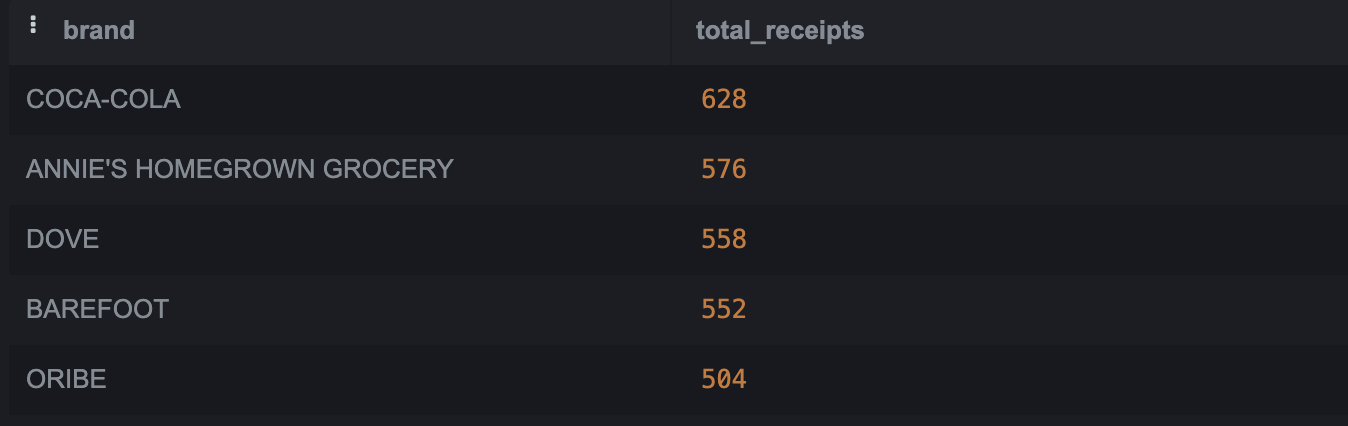

### 2. What are the top 5 brands by sales among users that have had their account for at least six months?

In [ ]:
SELECT
    p.brand,
    COUNT(t.barcode) AS total_sales -- Count how many times each brand appears in transactions
FROM user u
JOIN transactions t ON u.id = t.user_id -- Join transactions with user table to filter by account age
JOIN products p ON t.barcode = p.barcode -- Join with products to get brand information
WHERE
    u.created_date <= DATE('now', '-180 days') -- Only include users whose account was created at least 6 months ago
    AND p.BRAND IS NOT NULL -- Exclude rows where the brand is missing
    AND TRIM(p.BRAND) <> '' -- Exclude rows where the brand is blank or only spaces
GROUP BY
    p.brand -- Group by brand to count total transactions per brand
ORDER BY
    total_sales DESC -- Sort brands from highest to lowest transaction count
LIMIT 5; -- Return only the top 5 brands


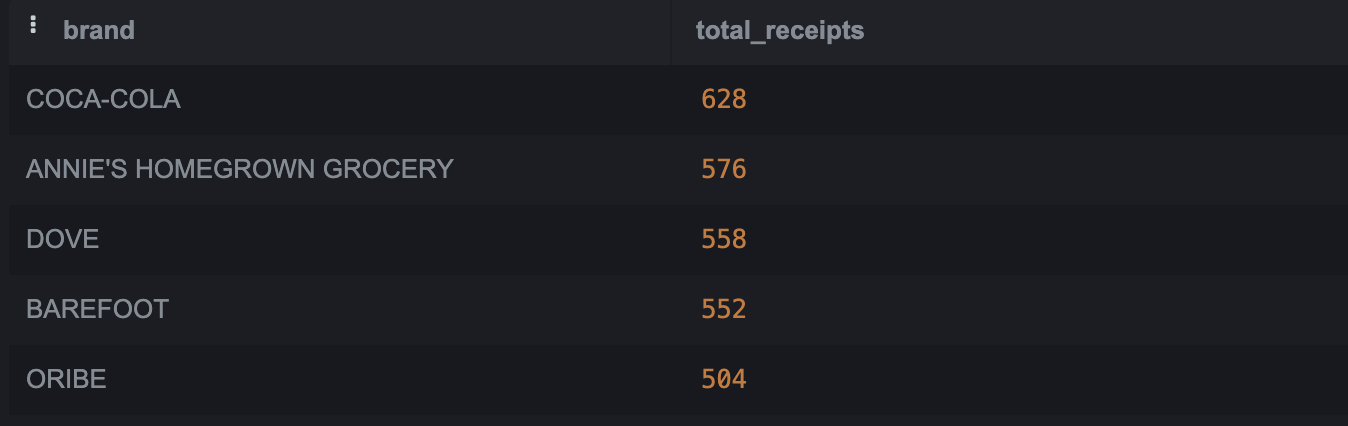

*When analyzing the top 5 brands by receipts scanned among users aged 21 and over and comparing it to the top brands by total sales among users with accounts older than six months, I found the same brands appearing in both lists.*

*Upon reviewing the user data, I discovered that all users aged 21 and over also happened to have created their accounts at least six months ago. This means both filters were essentially applied to the same user group, which explains why the results were identical.*

### 3. Which is the leading brand in the Dips & Salsa category?

*To answer this question, I defined the "leading brand" as the one with the highest number of transactions in the Dips & Salsa category. This assumes that greater transaction volume is a reasonable proxy for popularity or customer preference. I also assumed that the products table contains a category column that accurately labels items under “Dips & Salsa.” To avoid counting invalid entries, I excluded records with missing or empty brand values. This approach gives a clean view of which brand in that category sees the most activity on the platform.*

In [ ]:
SELECT
    p.brand,                           -- Select the brand name
    COUNT(*) AS total_sales            -- Count how many times products from that brand appear in transactions
FROM transactions t
JOIN products p ON t.barcode = p.barcode  -- Join with products table to get category and brand info
WHERE
    p.category_1 = 'Dips & Salsa'     -- Filter to include only items in the Dips & Salsa category
    AND p.brand IS NOT NULL           -- Exclude rows where brand is missing
    AND TRIM(p.brand) <> ''           -- Exclude rows where brand is just empty spaces
GROUP BY p.brand                      -- Group by brand to aggregate counts
ORDER BY total_sales DESC             -- Sort by number of transactions in descending order
LIMIT 1;                              -- Return only the top brand


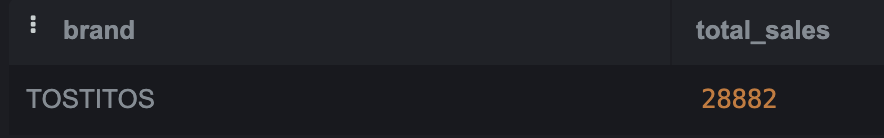

*According to the data, 'TOSTITOS' is the top-selling brand in this category, with 28,882 sales. This suggests it's a strong favorite among users scanning receipts with Dips & Salsa items.*

## Third: Communicate with Stakeholders

**Subject: Update on Data Quality and Key Insights**

Hello,

I wanted to share an update on my recent work with the data, along with some findings and a few areas where I could use your help.

**Key Data Quality Issues:**

1. **Missing or Inconsistent Data:** Some of the data is incomplete, and there are gaps in key areas. This is a problem because it can lead to inaccurate results or conclusions if we base any analysis on incomplete data.
   
2. **Duplicate Entries:** I’ve come across duplicate records in both the Transactions and Products tables. If we don’t clean up these duplicates, they will distort our analysis and could make it seem like a product was sold more times than it actually was, or transactions may appear more frequent than they are.
   
3. **Illogical Data:** There’s one instance where a user's "created date" is listed after their "birthdate". This doesn’t make sense because an account can’t be created before the user is born. This could be the result of a data entry error or a system glitch. If this isn’t corrected, it could lead to misleading assumptions about the user’s age or account history.
   
4. **Spelling and Formatting Issues:** There are some spelling mistakes in brand and store names, and inconsistencies in how "gender" is recorded. These issues can cause confusion when trying to analyze or visualize the data, as different variations of the same value could be treated as separate entries.
   
5. **Misformatted Dates and Units:** Some birthdates aren't formatted consistently, and there’s a mix of numbers and letters in the "final quantity" column in Transactions that needs to be standardized to help avoid confusion and ensure that we can analyze the data accurately.

**Interesting Trend:**
When I looked at the top brands based on receipts scanned by users over 21 and compared it to the brands with the most total sales among users who’ve had accounts for more than six months, the same brands showed up in both lists. Upon further investigation, I found that all users over 21 also have accounts older than six months, which is why both lists were the same.

**Confusing Data Point:**
In the Transactions table, I noticed that in some cases, the purchase date is listed as being after the scan date, which doesn’t seem right and is a bit confusing.

**What I Need Help With:**
To make sure the data is accurate, it would be great if you could help clarify a few things:
- How should we handle the issue where the "created date" is listed after the "birth date" for some users?
- Can you provide more details about the “final quantity” field in the Transactions table so we can standardize the way it’s recorded?

By addressing these points, we can ensure that our data is reliable and that the insights we draw from it are meaningful. Please let me know if you need more information or have any questions.

Best regards,  
Prashanti  
Senior Data Analyst  